# PART 1 — BUILD RAG


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


FAISS → local vector database

SentenceTransformers → embeddings

LangChain → RAG orchestration (latest)

pdfplumber → read PDFs

python-docx → read Word docs

gpt4all → local LLM (offline)

In [3]:
!pip install faiss-cpu sentence-transformers langchain pdfplumber python-docx gpt4all --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 79.3 MB/s eta 0:00:00


In [4]:
!pip install faiss-cpu sentence-transformers transformers accelerate
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


##loading files amd pdfs

In [5]:
import pdfplumber
import json
import glob

texts = []

# 1️⃣ Load all PDFs in the folder
pdf_files = glob.glob("/content/drive/MyDrive/Environmental_ai_healthcare_system/data/pdfs/*.pdf")
for pdf_file in pdf_files:
    with pdfplumber.open(pdf_file) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                texts.append(page_text)

# 2️⃣ Load JSON knowledge file
json_file_path = "/content/drive/MyDrive/Environmental_ai_healthcare_system/data/env_health_knowledge.json"
with open(json_file_path, "r", encoding="utf-8") as f:
    json_data = json.load(f)

# Assuming JSON has a structure like {"air_pollution": [...], "garbage_dirty": [...], ...}
for key, value_list in json_data.items():
    # value_list could be list of strings
    for item in value_list:
        texts.append(item)

print(f"Total documents loaded for RAG: {len(texts)}")

Total documents loaded for RAG: 668


In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Initialize embedding model (offline, free)
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings for all loaded texts
embeddings = np.array([embedder.encode(text) for text in texts], dtype='float32')

print(f"Generated embeddings for {len(texts)} documents.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generated embeddings for 668 documents.


In [7]:
import faiss

# Create FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print(f"FAISS index created with {index.ntotal} vectors.")
faiss.write_index(index, "/content/drive/MyDrive/Environmental_ai_healthcare_system/faiss_index.index")

FAISS index created with 668 vectors.


In [8]:
import pickle

with open("/content/drive/MyDrive/Environmental_ai_healthcare_system/documents.pkl", "wb") as f:
    pickle.dump(texts, f)

print("Documents saved!")

Documents saved!


In [ ]:
def retrieve(query, top_k=5):
    query_vec = embedder.encode([query])
    D, I = index.search(query_vec, top_k)
    retrieved = [texts[i] for i in I[0]]
    return "\n".join(retrieved)

# Example
query = "What diseases are caused by stagnant water?"
context = retrieve(query)
print(context)

Stagnant water is a common breeding ground for mosquitoes, which can spread diseases like dengue and malaria.
It can also lead to waterborne illnesses such as cholera, typhoid, and diarrhea due to bacterial growth.
Regular cleaning and proper drainage can prevent health risks associated with stagnant water.
Leaving water standing in containers, puddles, or clogged drains increases the risk of infectious diseases.
ANGIOTHERAPY REVIEW
infections and contribute to environmental imbalances (Donatus health concern, especially in tropical and subtropical regions. The
et al., 2022). Mosquito abundance is influenced by factors such as disease is primarily transmitted through the bite of Aedes
fluctuations in egg-laying patterns and larval overcrowding in water mosquitoes (Nakase et al., 2023), which are also known carriers of
environments (Laursen et al., 2023). The development of mosquito other viruses, including those responsible for dengue hemorrhagic
larvae into adult mosquitoes typically 

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_PATH = "/content/drive/MyDrive/Environmental_ai_healthcare_system/model/llama3_1b"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    device_map=None,
    dtype=torch.float16 if device == "cuda" else torch.float32
)

model.to(device)
model.eval()

print(f"Running on: {device}")



Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Running on: cuda


##prompt generation for the rag model

---



In [ ]:
def generate_answer(query, context, predicted_label):
    if query is None or query.strip() == "":
        mode = "report"
    else:
        mode = "question"

    # Task instructions based on label (for report mode)
    if mode == "report":

        if predicted_label == "stagnant_water":
            task = """
List ONLY 3 diseases. Do not list more or fewer caused by stagnant water.
Must include dengue and malaria.
Then list exactly 3 preventive measures.
Then list exactly 2 health guidelines.
Keep each bullet under 10 words.
Do not list more than 3 diseases.
"""

        elif predicted_label == "air_pollution":
            task = """
List ONLY 3 diseases. Do not list more or fewer caused by air pollution.
Then list exactly 3 preventive measures.
Then list exactly 2 health guidelines.
Keep each bullet under 10 words.
"""

        elif predicted_label == "garbage_dirty":
            task = """
List ONLY 3  common diseases.Do not list more or fewer caused by garbage accumulation.
Focus on realistic infectious diseases only.
Do not list cancers or unrelated illnesses.
Then list exactly 3 preventive measures.
Then list exactly 2 health guidelines.
Keep each bullet under 10 words.
"""

        elif predicted_label == "hygienic_environment":
            task = """
Describe 3 health benefits of a clean environment.
Then list 3 preventive practices to maintain hygiene.
Then list 2 general health promotion guidelines.
Keep each bullet under 10 words.
Do not list diseases.
"""

        else:
            task = "Explain the health impact concisely."

        prompt = f"""
You are an environmental health expert.

Detected Condition: {predicted_label}

Context:
{context}

Task:
{task}

Format:

Section 1:
- Bullet points only

Section 2:
- Bullet points only

Section 3:
- Bullet points only

Rules:
- No long paragraphs.
- No extra commentary.
- No tables.
- Stop after Section 3.
- Do not mention any pollution type other than the detected condition.
- Do not repeat section headers.
- Follow bullet count strictly.

Answer:
"""

    else:
        prompt = f"""
You are an environmental health expert.

Detected Condition: {predicted_label}

User Question:
{query}

Context:
{context}

Instructions:
- Answer the question directly and concisely.
- Stay relevant to the detected condition.
- Use evidence-based reasoning.
- Avoid unrelated pollution types.
- 4–6 sentences maximum.
-if possible any website link to support the statement can be given in some cases

Answer:
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=160,
            do_sample=False,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id
        )

        generated_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
        return tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()


#RAG DEMO



In [ ]:
while True:
    context = input("\nEnter pollution context (or type 'exit' to stop): ")
    if context.lower() == "exit":
        break

    query = input("Enter your question: ")

    response = generate_answer(query, context)

    print("Hello I am your Personal health care assistant.\nHow can I help you today?")

    print("\n--- Generated Response ---\n")
    print(response)


Enter pollution context (or type 'exit' to stop): exit


#IMAGE +RAG INTEGRATED SYSTEM

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image

In [ ]:
cnn_model = load_model(
    "/content/drive/MyDrive/Environmental_ai_healthcare_system/efficientnet_model.keras"
)

print("EfficientNetB0 model loaded successfully.")

EfficientNetB0 model loaded successfully.


In [ ]:
class_names = [
    "air_pollution",
    "garbage_dirty",
    "hygienic_environment",
    "stagnant_water"
]

In [ ]:
def predict_image(image_path):

    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = cnn_model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = float(np.max(predictions[0]) * 100)

    return predicted_class, confidence

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

def run_environmental_ai():

    print("Please choose an image file...")
    uploaded = files.upload()

    if not uploaded:
        print("No file selected.")
        return

    img_path = list(uploaded.keys())[0]

    # CNN Prediction
    predicted_label, confidence = predict_image(img_path)

    print("\n=================================")
    print("Predicted Condition:", predicted_label)
    print(f"Confidence: {confidence:.2f}%")
    print("=================================\n")

    # Show image
    img = image.load_img(img_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{predicted_label} ({confidence:.2f}%)")
    plt.show()

    print("\nHello. I am your Environmental Hygiene Assistant.")
    print("I analyze environmental conditions and provide risk assessment with preventive guidance.\n")

    # RAG Initial Report
    retrieval_query = f"Health risks and preventive measures related to {predicted_label}"
    retrieved_context = retrieve(retrieval_query)

    response = generate_answer("", retrieved_context, predicted_label)

    print("\n--- Environmental Health Analysis Report ---\n")
    print(response)

    # Follow-up loop
    while True:
        choice = input("\nDo you have any additional questions? (yes/no): ")

        if choice.lower() == "no":
            print("\nThank you for using the Environmental Health Advisory System.")
            print("Stay informed. Stay safe.")
            break

        elif choice.lower() == "yes":
            user_query = input("What would you like to know more about?: ")

            retrieval_query = f"{user_query} related to {predicted_label} environmental condition"
            retrieved_context = retrieve(retrieval_query)

            answer = generate_answer(user_query, retrieved_context, predicted_label)

            print("\nBased on retrieved environmental health information:\n")
            print(answer)

        else:
            print("Please type 'yes' or 'no'.")

##DEMO RAG IMPLEMENTED CLASS PREDICTION

Please choose an image file...


Saving images.jpg to images.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Predicted Condition: air_pollution
Confidence: 73.40%



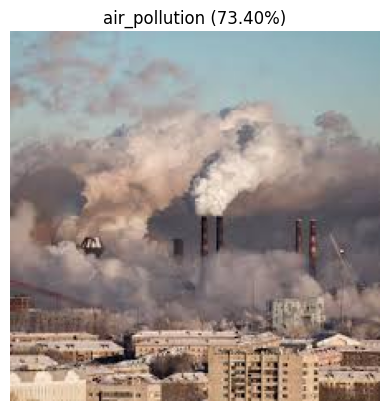


Hello. I am your Environmental Hygiene Assistant.
I analyze environmental conditions and provide risk assessment with preventive guidance.


--- Environmental Health Analysis Report ---

1. List three major causes of air pollutions – industrial emissions through fossil fuel combustion;
vehicular exhaust; resuspension/dust generation from roadsides/construction sites/cement factories;

2. Preventative measure against these types of air pollutions –

    i. Avoid using coal/biomass fireplaces/cooking stoves/gas cylinders/lamps/kerosene lamps/oil burners/etc.;
    
    ii. Use LPG/LNG gas cylinder instead of kerosene lamp/light oil stove/fireplace;
    
    iii. Keep windows closed when outside temperature rises above 30°C;
    
     iv. Reduce time spent near open fires/stove/smokestacks/volcanoes/towers/sprinklers/water tanks;
    
    
   v. Maintain proper ventilation system inside homes

Based on retrieved environmental health information:

What are the Disseases Caused?

Explanatio

In [ ]:
run_environmental_ai()